In [ ]:
!pip install einops albumentations

In [ ]:
# Cell 1: Config & tự tạo train_small.txt nếu cần

from pathlib import Path
import torch
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

DATA_ROOT    = Path(r"D:\HUS_22001541\AdvancedCV\Project\data\processed\2d")
LABELED_ROOT = DATA_ROOT / "labeled"

CONFIG_DIR        = Path(r"D:\HUS_22001541\AdvancedCV\Project\config")
BASE_TRAIN_FILE   = CONFIG_DIR / "train.txt"
VAL_SPLIT_FILE    = CONFIG_DIR / "val.txt"
TEST_SPLIT_FILE   = CONFIG_DIR / "test.txt"

USE_SMALL_TRAIN   = True          
N_TRAIN_BRAINS    = 120           
SLICE_STRIDE_TRAIN = 2            
SLICE_STRIDE_EVAL  = 1            

# Huấn luyện
BATCH_SIZE  = 8                  
NUM_EPOCHS  = 15                  
LR          = 1e-4

CONFIG_DIR.mkdir(parents=True, exist_ok=True)

if USE_SMALL_TRAIN:
    TRAIN_SPLIT_FILE = CONFIG_DIR / "train_small.txt"
    if not TRAIN_SPLIT_FILE.exists():
        with open(BASE_TRAIN_FILE, "r", encoding="utf-8") as f:
            brains = [line.strip() for line in f if line.strip()]
        print("Tổng số Brain trong train.txt:", len(brains))
        random.seed(42)
        random.shuffle(brains)
        brains_small = brains[:N_TRAIN_BRAINS]
        with open(TRAIN_SPLIT_FILE, "w", encoding="utf-8") as f:
            for bid in brains_small:
                f.write(bid + "\n")
        print("Đã tạo train_small.txt với", len(brains_small), "ca")
    else:
        print("Đã có train_small.txt, dùng lại.")
else:
    TRAIN_SPLIT_FILE = BASE_TRAIN_FILE

print("TRAIN_SPLIT_FILE:", TRAIN_SPLIT_FILE)
print("VAL_SPLIT_FILE:", VAL_SPLIT_FILE)
print("TEST_SPLIT_FILE:", TEST_SPLIT_FILE)


Using device: cuda
Đã có train_small.txt, dùng lại.
TRAIN_SPLIT_FILE: D:\HUS_22001541\AdvancedCV\Project\config\train_small.txt
VAL_SPLIT_FILE: D:\HUS_22001541\AdvancedCV\Project\config\val.txt
TEST_SPLIT_FILE: D:\HUS_22001541\AdvancedCV\Project\config\test.txt


In [3]:
# Cell 2: Metric functions (Dice, IoU, Hausdorff95)

import math
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion
import torch.nn.functional as F

def compute_dice_iou_per_channel(logits, targets, threshold=0.5, eps=1e-6):
    """
    logits, targets: (B, C, H, W)
    Trả về:
      dice_per_channel: (C,)
      iou_per_channel:  (C,)
    Cho 3 kênh: WT, TC, ET.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    B, C, H, W = preds.shape
    preds_flat   = preds.view(B, C, -1)
    targets_flat = targets.view(B, C, -1)

    intersection = (preds_flat * targets_flat).sum(dim=-1)   # (B, C)
    pred_sum   = preds_flat.sum(dim=-1)
    target_sum = targets_flat.sum(dim=-1)
    union = pred_sum + target_sum - intersection

    dice = (2.0 * intersection + eps) / (pred_sum + target_sum + eps)
    iou  = (intersection + eps) / (union + eps)

    mask_valid = (target_sum + pred_sum) > 0
    dice = torch.where(mask_valid, dice, torch.ones_like(dice))
    iou  = torch.where(mask_valid, iou,  torch.ones_like(iou))

    dice_per_channel = dice.mean(dim=0)  # (C,)
    iou_per_channel  = iou.mean(dim=0)
    return dice_per_channel, iou_per_channel


def hausdorff95_binary(mask_pred, mask_true):
    """
    mask_pred, mask_true: numpy array 2D (bool hoặc 0/1)
    Trả về Hausdorff distance 95% (pixel units).
    """
    mask_pred = mask_pred.astype(bool)
    mask_true = mask_true.astype(bool)

    if not mask_pred.any() and not mask_true.any():
        return 0.0
    if not mask_pred.any() or not mask_true.any():
        return 999.0

    footprint = np.ones((3, 3), dtype=bool)
    eroded_pred = binary_erosion(mask_pred, structure=footprint, border_value=0)
    eroded_true = binary_erosion(mask_true, structure=footprint, border_value=0)
    surface_pred = mask_pred ^ eroded_pred
    surface_true = mask_true ^ eroded_true

    if not surface_pred.any():
        surface_pred = mask_pred
    if not surface_true.any():
        surface_true = mask_true

    dist_true = distance_transform_edt(~surface_true)
    dists_pred_to_true = dist_true[surface_pred]

    dist_pred = distance_transform_edt(~surface_pred)
    dists_true_to_pred = dist_pred[surface_true]

    all_dists = np.concatenate([dists_pred_to_true, dists_true_to_pred])
    if all_dists.size == 0:
        return 0.0
    return float(np.percentile(all_dists, 95))


In [ ]:
# Cell 3: Dataset BraTS 2D (Tự động Resize về 256x256 cho TransUNet)

from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

class Brats2DSegDataset(Dataset):
    def __init__(self, labeled_root: Path, split_file: Path, slice_stride: int = 1, is_train=False):
        self.labeled_root = Path(labeled_root)
        self.split_file   = Path(split_file)
        self.slice_stride = slice_stride
        self.brain_ids    = self._load_brain_ids(split_file)
        self.samples      = self._collect_samples()
    
        if is_train:
            self.transform = A.Compose([
                A.Resize(height=256, width=256),
                A.HorizontalFlip(p=0.5),
                A.Rotate(limit=15, p=0.5),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(height=256, width=256),
                ToTensorV2()
            ])

    def _load_brain_ids(self, split_file: Path):
        with open(split_file, "r", encoding="utf-8") as f:
            ids = [line.strip() for line in f if line.strip()]
        return ids

    def _collect_samples(self):
        samples = []
        for bid in self.brain_ids:
            brain_dir = self.labeled_root / bid
            mask_dir  = brain_dir / "mask"
            if not mask_dir.exists(): continue
            
            mask_files = sorted(mask_dir.glob("mask_*.png"))
            mask_files = mask_files[::self.slice_stride]

            for mf in mask_files:
                k_str = mf.stem.split("_")[-1]
                samples.append({
                    "brain_id": bid, "slice_idx": k_str,
                    "flair": brain_dir / "flair" / f"flair_{k_str}.png",
                    "t1":    brain_dir / "t1"    / f"t1_{k_str}.png",
                    "t1ce":  brain_dir / "t1ce"  / f"t1ce_{k_str}.png",
                    "t2":    brain_dir / "t2"    / f"t2_{k_str}.png",
                    "mask":  mf,
                })
        print(f"Found {len(samples)} slices for {self.split_file.name}")
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        
        # Load ảnh gốc (dạng float 0-1 chưa resize)
        flair = np.array(Image.open(s["flair"]), dtype=np.float32) / 255.0
        t1    = np.array(Image.open(s["t1"]), dtype=np.float32) / 255.0
        t1ce  = np.array(Image.open(s["t1ce"]), dtype=np.float32) / 255.0
        t2    = np.array(Image.open(s["t2"]), dtype=np.float32) / 255.0
        mask_raw = np.array(Image.open(s["mask"]), dtype=np.int32) # (H,W) class 0,1,2,3

        # Stack thành (H, W, 4) để Albumentations xử lý
        img_stack = np.stack([flair, t1, t1ce, t2], axis=-1) 

        # Áp dụng Resize 256x256 và Augmentation
        augmented = self.transform(image=img_stack, mask=mask_raw)
        img_tensor = augmented['image']      # (4, 256, 256)
        mask_aug   = augmented['mask']       # (256, 256)

        # Tách mask ra 3 kênh (WT, TC, ET)
        # Lưu ý: mask_raw có giá trị 0, 1, 2, 4 (hoặc 1,2,3 tùy process)
        # Code này giả định label input là: 0(bg), 1(NCR), 2(ED), 3(ET)
        wt = (mask_aug > 0).float()
        tc = ((mask_aug == 1) | (mask_aug == 3)).float()
        et = (mask_aug == 3).float()
        
        mask_tensor = torch.stack([wt, tc, et], dim=0) # (3, 256, 256)

        return img_tensor, mask_tensor

In [5]:
# Cell 4: TransUNet Architecture (Final Version)
import torch.nn as nn
from einops import rearrange

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class ViTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(mlp_dim, dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        return x + self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=3, img_dim=256):
        super().__init__()
        self.img_dim = img_dim
        # 1. CNN Encoder
        self.conv1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2) # -> 128
        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2) # -> 64
        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2) # -> 32 feature map
        
        # 2. Transformer Bottleneck
        self.patch_embed = nn.Conv2d(256, 512, kernel_size=1) # Project 256->512
        self.pos_embed = nn.Parameter(torch.zeros(1, 32*32, 512))
        self.blocks = nn.ModuleList([ViTBlock(512, 8, 1024) for _ in range(6)]) # 6 layers transformer
        self.norm = nn.LayerNorm(512)
        
        # 3. Decoder
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = ConvBlock(512, 256) 
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = ConvBlock(128, 64)
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        p1 = self.pool1(x1)
        x2 = self.conv2(p1)
        p2 = self.pool2(x2)
        x3 = self.conv3(p2)
        p3 = self.pool3(x3) # (B, 256, 32, 32)
        
        # Transformer
        emb = self.patch_embed(p3) # (B, 512, 32, 32)
        emb = rearrange(emb, 'b c h w -> b (h w) c')
        emb = emb + self.pos_embed
        for blk in self.blocks: emb = blk(emb)
        emb = self.norm(emb)
        emb = rearrange(emb, 'b (h w) c -> b c h w', h=32, w=32)
        
        # Decoder
        u1 = self.up1(emb)
        u1 = torch.cat([x3, u1], dim=1)
        d1 = self.dec1(u1)
        
        u2 = self.up2(d1)
        u2 = torch.cat([x2, u2], dim=1)
        d2 = self.dec2(u2)
        
        u3 = self.up3(d2)
        u3 = torch.cat([x1, u3], dim=1)
        d3 = self.dec3(u3)
        
        return self.out_conv(d3)

# Khởi tạo model
model = TransUNet(in_channels=4, num_classes=3, img_dim=256).to(DEVICE)
print("TransUNet 256x256 initialized.")

TransUNet 256x256 initialized.


In [6]:
# Cell 5: Loss functions (Dice + BCE)

class DiceLossMultiChannel(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()
        B, C, H, W = probs.shape
        probs   = probs.view(B, C, -1)
        targets = targets.view(B, C, -1)

        intersection = (probs * targets).sum(dim=-1)
        denom = probs.sum(dim=-1) + targets.sum(dim=-1)
        dice = (2.0 * intersection + self.eps) / (denom + self.eps)
        return 1.0 - dice.mean()


dice_loss_fn = DiceLossMultiChannel()
bce_loss_fn  = nn.BCEWithLogitsLoss()

def combined_loss(logits, targets, lambda_dice=1.0, lambda_bce=1.0):
    ld = dice_loss_fn(logits, targets)
    lb = bce_loss_fn(logits, targets)
    return lambda_dice * ld + lambda_bce * lb, ld, lb

print("Loss functions ready.")

Loss functions ready.


In [7]:
# Cell 6: DataLoader (Updated)
from torch.utils.data import DataLoader  # <--- Bắt buộc phải có dòng này

# Tạo Dataset (đã có resize 256x256 bên trong class Brats2DSegDataset)
train_dataset = Brats2DSegDataset(LABELED_ROOT, TRAIN_SPLIT_FILE, slice_stride=SLICE_STRIDE_TRAIN, is_train=True)
val_dataset   = Brats2DSegDataset(LABELED_ROOT, VAL_SPLIT_FILE, slice_stride=SLICE_STRIDE_EVAL, is_train=False)
test_dataset  = Brats2DSegDataset(LABELED_ROOT, TEST_SPLIT_FILE, slice_stride=SLICE_STRIDE_EVAL, is_train=False)

# Tạo DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,      # Windows nên để 0
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

print(f"Ready: Train ({len(train_dataset)}), Val ({len(val_dataset)})")

Found 9360 slices for train_small.txt
Found 8525 slices for val.txt
Found 8680 slices for test.txt
Ready: Train (9360), Val (8525)


In [8]:
# Cell X: Kiểm tra kích thước output và đếm số tham số của UNet2D

import torch

# Giả sử input của bạn là (B, 4, H, W), ví dụ H = W = 240
dummy_input = torch.randn(1, 4, 256, 256).to(DEVICE)  # sửa 240 nếu ảnh bạn khác size

model.eval()
with torch.no_grad():
    dummy_output = model(dummy_input)

print("Input shape :", tuple(dummy_input.shape))
print("Output shape:", tuple(dummy_output.shape))

# Đếm số tham số
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"Total params        : {total_params:,}")
print(f"Trainable params    : {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")

# (tuỳ chọn) ước lượng dung lượng model (float32 ~ 4 bytes/param)
model_size_mb = total_params * 4 / (1024**2)
print(f"~ Model size        : {model_size_mb:.2f} MB (float32)")


Input shape : (1, 4, 256, 256)
Output shape: (1, 3, 256, 256)
Total params        : 17,435,267
Trainable params    : 17,435,267
Non-trainable params: 0
~ Model size        : 66.51 MB (float32)


In [9]:
# Cell 7: Train + Validation (AMP) + lưu log CSV (Đã sửa tên file save)

import pandas as pd
from torch.cuda.amp import GradScaler, autocast

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# Lưu ý: GradScaler và autocast có thể cảnh báo deprecated ở pytorch mới, 
# nhưng vẫn chạy tốt. Nếu muốn fix warning hãy dùng torch.amp.GradScaler("cuda", ...)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss  = 0.0
    running_dice_score = torch.zeros(3, device=DEVICE)
    running_iou_score  = torch.zeros(3, device=DEVICE)
    n_batches = 0

    for imgs, masks in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast(enabled=scaler.is_enabled()):
            logits = model(imgs)
            loss, loss_dice, loss_bce = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            dice_c, iou_c = compute_dice_iou_per_channel(logits, masks)
            running_loss      += loss.item()
            running_dice_loss += loss_dice.item()
            running_bce_loss  += loss_bce.item()
            running_dice_score += dice_c
            running_iou_score  += iou_c
            n_batches += 1

    epoch_loss      = running_loss      / max(1, n_batches)
    epoch_dice_loss = running_dice_loss / max(1, n_batches)
    epoch_bce_loss  = running_bce_loss  / max(1, n_batches)
    epoch_dice_score = (running_dice_score / max(1, n_batches)).detach().cpu().numpy()
    epoch_iou_score  = (running_iou_score  / max(1, n_batches)).detach().cpu().numpy()
    return epoch_loss, epoch_dice_loss, epoch_bce_loss, epoch_dice_score, epoch_iou_score


def eval_one_epoch(model, loader, epoch, split="Val"):
    model.eval()
    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss  = 0.0
    running_dice_score = torch.zeros(3, device=DEVICE)
    running_iou_score  = torch.zeros(3, device=DEVICE)
    n_batches = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            logits = model(imgs)
            loss, loss_dice, loss_bce = combined_loss(logits, masks)
            dice_c, iou_c = compute_dice_iou_per_channel(logits, masks)

            running_loss      += loss.item()
            running_dice_loss += loss_dice.item()
            running_bce_loss  += loss_bce.item()
            running_dice_score += dice_c
            running_iou_score  += iou_c
            n_batches += 1

    epoch_loss      = running_loss      / max(1, n_batches)
    epoch_dice_loss = running_dice_loss / max(1, n_batches)
    epoch_bce_loss  = running_bce_loss  / max(1, n_batches)
    epoch_dice_score = (running_dice_score / max(1, n_batches)).detach().cpu().numpy()
    epoch_iou_score  = (running_iou_score  / max(1, n_batches)).detach().cpu().numpy()
    return epoch_loss, epoch_dice_loss, epoch_bce_loss, epoch_dice_score, epoch_iou_score


history = {
    "epoch": [],
    "train_loss": [], "train_dice_loss": [], "train_bce_loss": [],
    "val_loss": [],   "val_dice_loss": [],   "val_bce_loss": [],
    "train_dice_WT": [], "train_dice_TC": [], "train_dice_ET": [],
    "val_dice_WT": [],   "val_dice_TC": [],   "val_dice_ET": [],
    "train_iou_WT": [], "train_iou_TC": [], "train_iou_ET": [],
    "val_iou_WT": [],   "val_iou_TC": [],   "val_iou_ET": [],
}

best_val_dice = -1.0
# ĐÃ SỬA: Đổi tên file lưu model thành transunet...
best_model_path = "transunet_brats20_best.pth" 

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_dice_loss, tr_bce_loss, tr_dice_score, tr_iou_score = train_one_epoch(
        model, train_loader, optimizer, epoch
    )
    val_loss, val_dice_loss, val_bce_loss, val_dice_score, val_iou_score = eval_one_epoch(
        model, val_loader, epoch, split="Val"
    )

    print(f"Epoch: {epoch} / {NUM_EPOCHS}")
    print(
        f"Train loss: {tr_loss:.5f}, DiceLoss: {tr_dice_loss:.5f}, BCE: {tr_bce_loss:.5f} | "
        f"Val loss: {val_loss:.5f}, DiceLoss: {val_dice_loss:.5f}, BCE: {val_bce_loss:.5f}"
    )
    print(
        f"    Train Dice score WT/TC/ET: {tr_dice_score} | "
        f"Val Dice score WT/TC/ET: {val_dice_score}"
    )
    print(
        f"    Train IoU  score WT/TC/ET: {tr_iou_score} | "
        f"Val IoU  score WT/TC/ET: {val_iou_score}"
    )

    # Lưu history
    history["epoch"].append(epoch)
    history["train_loss"].append(float(tr_loss))
    history["train_dice_loss"].append(float(tr_dice_loss))
    history["train_bce_loss"].append(float(tr_bce_loss))
    history["val_loss"].append(float(val_loss))
    history["val_dice_loss"].append(float(val_dice_loss))
    history["val_bce_loss"].append(float(val_bce_loss))

    history["train_dice_WT"].append(float(tr_dice_score[0]))
    history["train_dice_TC"].append(float(tr_dice_score[1]))
    history["train_dice_ET"].append(float(tr_dice_score[2]))
    history["val_dice_WT"].append(float(val_dice_score[0]))
    history["val_dice_TC"].append(float(val_dice_score[1]))
    history["val_dice_ET"].append(float(val_dice_score[2]))

    history["train_iou_WT"].append(float(tr_iou_score[0]))
    history["train_iou_TC"].append(float(tr_iou_score[1]))
    history["train_iou_ET"].append(float(tr_iou_score[2]))
    history["val_iou_WT"].append(float(val_iou_score[0]))
    history["val_iou_TC"].append(float(val_iou_score[1]))
    history["val_iou_ET"].append(float(val_iou_score[2]))

    mean_val_dice_score = float(val_dice_score.mean())
    if mean_val_dice_score > best_val_dice:
        best_val_dice = mean_val_dice_score
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Saved new best model with mean Dice score={best_val_dice:.4f}")

df_log = pd.DataFrame(history)
# ĐÃ SỬA: Đổi tên file log thành transunet...
df_log.to_csv("transunet_brats20_training_log.csv", index=False) 
print("Đã lưu log training vào transunet_brats20_training_log.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_23416\3016677289.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
C:\Users\Admin\AppData\Local\Temp\ipykernel_23416\3016677289.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=scaler.is_enabled()):


Epoch: 1 / 15
Train loss: 1.12684, DiceLoss: 0.91488, BCE: 0.21196 | Val loss: 0.94739, DiceLoss: 0.87203, BCE: 0.07536
    Train Dice score WT/TC/ET: [0.70689607 0.70431805 0.668747  ] | Val Dice score WT/TC/ET: [0.8196496  0.84048396 0.8532697 ]
    Train IoU  score WT/TC/ET: [0.664632   0.67258054 0.64108574] | Val IoU  score WT/TC/ET: [0.78638995 0.81206703 0.8271126 ]
  --> Saved new best model with mean Dice score=0.8378
Epoch: 2 / 15
Train loss: 0.84177, DiceLoss: 0.80455, BCE: 0.03722 | Val loss: 0.81426, DiceLoss: 0.79183, BCE: 0.02243
    Train Dice score WT/TC/ET: [0.7499885  0.75457585 0.75059944] | Val Dice score WT/TC/ET: [0.7022973  0.79064167 0.79464763]
    Train IoU  score WT/TC/ET: [0.71136343 0.7244638  0.7236374 ] | Val IoU  score WT/TC/ET: [0.6627631 0.762222  0.7677665]
Epoch: 3 / 15
Train loss: 0.78983, DiceLoss: 0.77205, BCE: 0.01778 | Val loss: 0.80046, DiceLoss: 0.78385, BCE: 0.01661
    Train Dice score WT/TC/ET: [0.74067956 0.76860565 0.7845935 ] | Val Dice

In [ ]:
# Cell 8: Demo Inference (Ngẫu nhiên từ tập TEST)

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Config & Load Model
DEVICE_INFER = torch.device("cpu") # Test trên CPU
MODEL_PATH = "unet2d_brats20_best.pth"
IMG_SIZE = 256

# Load lại kiến trúc TransUNet
model_infer = TransUNet(in_channels=4, num_classes=3, img_dim=IMG_SIZE).to(DEVICE_INFER)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE_INFER)
model_infer.load_state_dict(state_dict)
model_infer.eval()

# 2. Chọn ngẫu nhiên 1 sample từ tập TEST
# ĐÃ SỬA: Dùng test_dataset thay vì val_dataset
DATASET_TO_USE = test_dataset 

if len(DATASET_TO_USE) == 0:
    print("⚠ Tập Test đang trống! Kiểm tra lại đường dẫn hoặc file split.")
else:
    rand_idx = random.randint(0, len(DATASET_TO_USE) - 1)
    sample_info = DATASET_TO_USE.samples[rand_idx]
    brain_id = sample_info["brain_id"]
    slice_idx = sample_info["slice_idx"]

    print(f"🎲 Randomly selected from TEST: {brain_id} - Slice {slice_idx} (Index: {rand_idx})")

    # 3. Lấy dữ liệu và Inference
    img_tensor, mask_tensor = DATASET_TO_USE[rand_idx] # (4, 256, 256)

    input_tensor = img_tensor.unsqueeze(0).to(DEVICE_INFER)
    with torch.no_grad():
        logits = model_infer(input_tensor)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()

    # 4. Hàm hiển thị màu (Overlay)
    def make_overlay(img_bg, mask_3ch):
        # img_bg: (H, W), mask_3ch: (3, H, W)
        rgb = np.stack([img_bg]*3, axis=-1)
        # Normalize nền về 0-1
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        
        colors = [
            np.array([1, 0, 0]), # WT - Đỏ
            np.array([0, 1, 0]), # TC - Xanh lá
            np.array([0, 0, 1])  # ET - Xanh dương
        ]
        overlay = rgb.copy()
        for i in range(3):
            mask_i = mask_3ch[i] > 0.5
            # Pha màu: 60% ảnh gốc + 40% màu mask
            overlay[mask_i] = overlay[mask_i] * 0.6 + colors[i] * 0.4
        return overlay

    # Lấy kênh T1CE (channel 2) làm nền cho rõ khối u
    t1ce = img_tensor.numpy()[2]

    gt_overlay = make_overlay(t1ce, mask_tensor.numpy())
    pred_overlay = make_overlay(t1ce, preds[0].cpu().numpy())

    # Vẽ hình
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title(f"Thực tế (Ground Truth)\n{brain_id} - Slice {slice_idx}")
    plt.imshow(gt_overlay)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"TransUNet Dự đoán (Test)\n(Red: WT, Green: TC, Blue: ET)")
    plt.imshow(pred_overlay)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Device: cuda
-> Da load Model TransUNet!
🔍 Dang quet tim lat cat co khoi u (vui long doi)...
✅ Tim thay! Brain_115 - Slice 066 (lan thu 2)


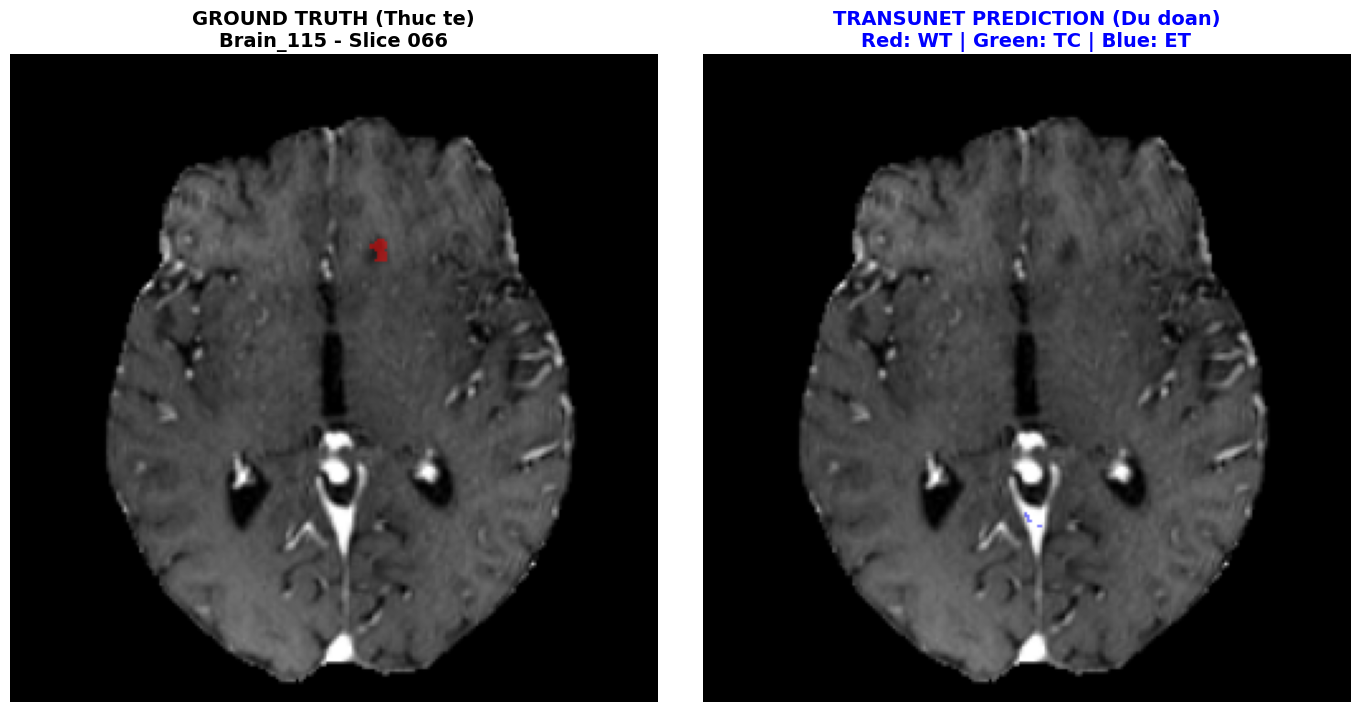

In [24]:
# Cell 8: Demo Inference (Tự động tìm lát cắt CÓ KHỐI U để hiển thị)

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# ================= CẤU HÌNH =================
DEVICE_INFER = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH   = "transunet_brats20_best.pth"
IMG_SIZE     = 256
DATASET_TO_USE = test_dataset # Dùng tập Test
# ============================================

print(f"Device: {DEVICE_INFER}")

# 1. Load Model
try:
    model_infer = TransUNet(in_channels=4, num_classes=3, img_dim=IMG_SIZE).to(DEVICE_INFER)
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE_INFER)
    model_infer.load_state_dict(state_dict)
    model_infer.eval()
    print("-> Da load Model TransUNet!")
except FileNotFoundError:
    print(f"❌ Loi: Khong tim thay file {MODEL_PATH}")
    raise

# 2. Vòng lặp tìm kiếm sample CÓ KHỐI U
print("🔍 Dang quet tim lat cat co khoi u (vui long doi)...")
max_retries = 200 # Thử tối đa 200 lần
found = False

for i in range(max_retries):
    rand_idx = random.randint(0, len(DATASET_TO_USE) - 1)
    img_tensor, mask_tensor = DATASET_TO_USE[rand_idx]
    
    # Kiểm tra xem mask có khối u không (tổng pixels > 0)
    if mask_tensor.sum() > 0:
        found = True
        sample_info = DATASET_TO_USE.samples[rand_idx]
        brain_id = sample_info["brain_id"]
        slice_idx = sample_info["slice_idx"]
        print(f"✅ Tim thay! {brain_id} - Slice {slice_idx} (lan thu {i+1})")
        break

if not found:
    print("⚠ Khong tim thay lát cắt nào có u sau 200 lần thử. (Check lại dataset)")
else:
    # 3. Inference
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE_INFER)
    with torch.no_grad():
        logits = model_infer(input_tensor)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()

    # 4. Hàm hiển thị màu
    def make_overlay(img_bg, mask_3ch):
        rgb = np.stack([img_bg]*3, axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        
        colors = [
            np.array([1, 0, 0]), # WT: Đỏ
            np.array([0, 1, 0]), # TC: Xanh Lá
            np.array([0, 0, 1])  # ET: Xanh Dương
        ]
        
        overlay = rgb.copy()
        for i in range(3):
            mask_i = mask_3ch[i] > 0.5
            if mask_i.sum() > 0:
                # Pha màu đậm hơn chút (0.5) cho dễ nhìn
                overlay[mask_i] = overlay[mask_i] * 0.5 + colors[i] * 0.5 
        return overlay

    t1ce = img_tensor.numpy()[2] # Lấy kênh T1CE làm nền
    
    gt_overlay = make_overlay(t1ce, mask_tensor.numpy())
    pred_overlay = make_overlay(t1ce, preds[0].cpu().numpy())

    # 5. Vẽ
    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.title(f"GROUND TRUTH (Thuc te)\n{brain_id} - Slice {slice_idx}", fontsize=14, fontweight='bold')
    plt.imshow(gt_overlay)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"TRANSUNET PREDICTION (Du doan)\nRed: WT | Green: TC | Blue: ET", fontsize=14, fontweight='bold', color='blue')
    plt.imshow(pred_overlay)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Device: cuda
Dang tim kiem: Brain_011 - Slice 75...
-> Model TransUNet loaded!
Found 39990 slices for train.txt
✅ Da tim thay chinh xac slice 75!
Processing: Brain_011 - Slice 075


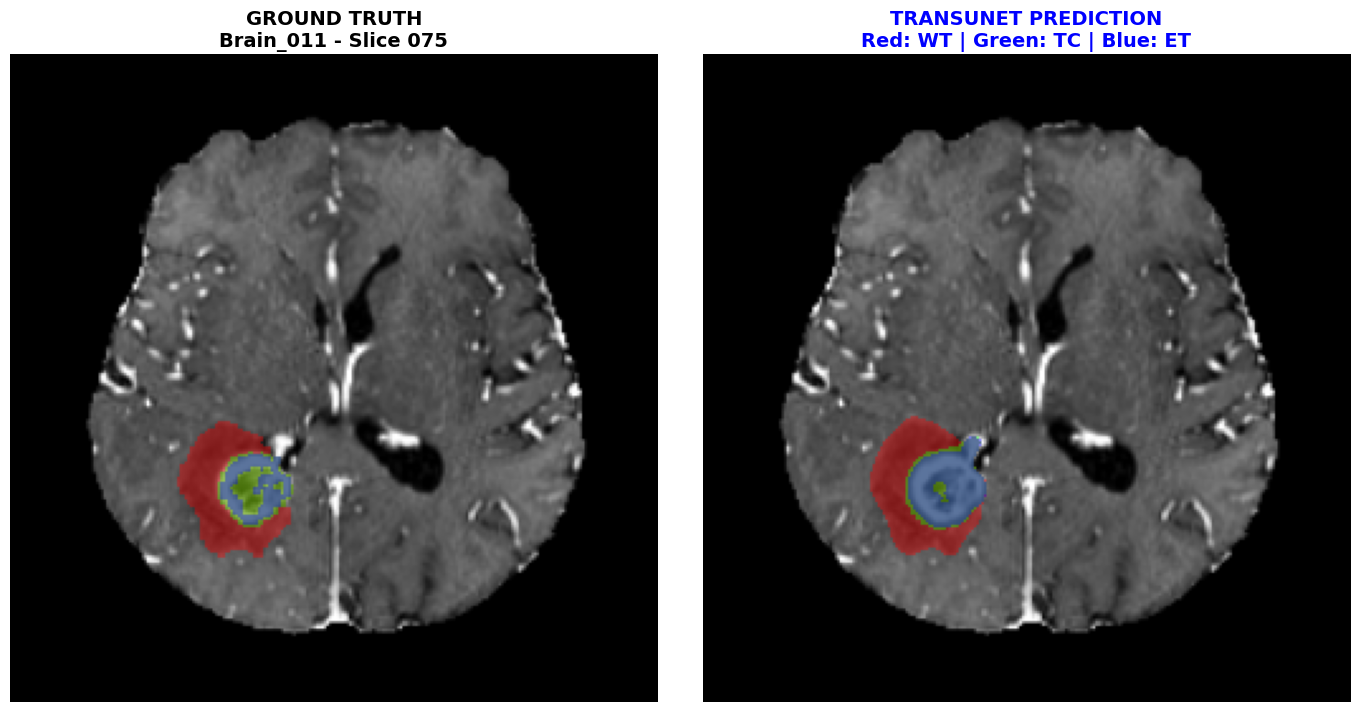

In [25]:
# Cell 8: Demo Inference (Chọn Brain ID & Slice cụ thể - Phiên bản TransUNet)

import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ================= CẤU HÌNH MỤC TIÊU =================
TARGET_BRAIN_ID = "Brain_011"   # Nhập tên Brain bạn muốn soi
TARGET_SLICE    = 75            # Nhập số lát cắt (VD: 75)
# Lưu ý: Brain_011 thường nằm trong file train.txt, nên ta dùng BASE_TRAIN_FILE
SPLIT_FILE_TO_SEARCH = BASE_TRAIN_FILE 
# =====================================================

# 1. Config & Load Model
DEVICE_INFER = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH   = "transunet_brats20_best.pth" # File model TransUNet
IMG_SIZE     = 256

print(f"Device: {DEVICE_INFER}")
print(f"Dang tim kiem: {TARGET_BRAIN_ID} - Slice {TARGET_SLICE}...")

# Load Model
try:
    model_infer = TransUNet(in_channels=4, num_classes=3, img_dim=IMG_SIZE).to(DEVICE_INFER)
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE_INFER)
    model_infer.load_state_dict(state_dict)
    model_infer.eval()
    print("-> Model TransUNet loaded!")
except FileNotFoundError:
    print(f"❌ Loi: Khong tim thay file {MODEL_PATH}")
    raise

# 2. Tạo Dataset tạm để tìm kiếm (Dùng logic của TransUNet Dataset để tự động Resize)
# is_train=False để chỉ Resize chứ không xoay lật ảnh
search_dataset = Brats2DSegDataset(LABELED_ROOT, SPLIT_FILE_TO_SEARCH, slice_stride=1, is_train=False)

# 3. Thuật toán tìm kiếm thông minh (Giống Cell 8 cũ)
found_idx = -1
all_slices_of_brain = []
slice_indices_map = {} # Map: slice_int -> dataset_index

# Quét một lượt qua dataset
for i, s in enumerate(search_dataset.samples):
    if s["brain_id"] == TARGET_BRAIN_ID:
        s_idx = int(s["slice_idx"])
        all_slices_of_brain.append(s_idx)
        slice_indices_map[s_idx] = i

# Xử lý kết quả tìm kiếm
if not all_slices_of_brain:
    print(f"❌ KHONG TIM THAY {TARGET_BRAIN_ID} trong file {SPLIT_FILE_TO_SEARCH.name}")
    print("Gợi ý: Thử đổi sang file VAL_SPLIT_FILE hoặc TEST_SPLIT_FILE xem sao.")
else:
    all_slices_of_brain.sort()
    
    # Trường hợp 1: Tìm thấy chính xác
    if TARGET_SLICE in slice_indices_map:
        found_idx = slice_indices_map[TARGET_SLICE]
        print(f"✅ Da tim thay chinh xac slice {TARGET_SLICE}!")
        
    # Trường hợp 2: Không thấy, tìm lát gần nhất
    else:
        closest_slice = min(all_slices_of_brain, key=lambda x: abs(x - TARGET_SLICE))
        found_idx = slice_indices_map[closest_slice]
        print(f"⚠ Khong co slice {TARGET_SLICE}. Da chon lat gan nhat: {closest_slice}")

    # 4. Inference & Hiển thị
    if found_idx != -1:
        # Lấy dữ liệu từ dataset (đã được Resize 256x256 và chuẩn hóa)
        img_tensor, mask_tensor = search_dataset[found_idx]
        
        # Lấy thông tin hiển thị
        info = search_dataset.samples[found_idx]
        print(f"Processing: {info['brain_id']} - Slice {info['slice_idx']}")

        # Forward pass
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE_INFER)
        with torch.no_grad():
            logits = model_infer(input_tensor)
            probs  = torch.sigmoid(logits)
            preds  = (probs > 0.5).float()

        # Hàm Overlay màu
        def make_overlay(img_bg, mask_3ch):
            # img_bg: (H, W), mask_3ch: (3, H, W)
            rgb = np.stack([img_bg]*3, axis=-1)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
            
            colors = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]
            overlay = rgb.copy()
            for i in range(3):
                mask_i = mask_3ch[i] > 0.5
                if mask_i.sum() > 0:
                    overlay[mask_i] = overlay[mask_i] * 0.6 + colors[i] * 0.4
            return overlay

        t1ce = img_tensor.numpy()[2] # Kênh T1CE
        gt_overlay = make_overlay(t1ce, mask_tensor.numpy())
        pred_overlay = make_overlay(t1ce, preds[0].cpu().numpy())

        # Vẽ hình
        plt.figure(figsize=(14, 7))
        
        plt.subplot(1, 2, 1)
        plt.title(f"GROUND TRUTH\n{info['brain_id']} - Slice {info['slice_idx']}", fontsize=14, fontweight='bold')
        plt.imshow(gt_overlay)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f"TRANSUNET PREDICTION\nRed: WT | Green: TC | Blue: ET", fontsize=14, fontweight='bold', color='blue')
        plt.imshow(pred_overlay)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

In [26]:
# Cell 9: Evaluate toàn bộ test_loader (Phiên bản TransUNet)
# - Load best model TransUNet
# - Chạy qua test_loader
# - Tính Dice / IoU trung bình cho WT, TC, ET và mean

import torch
import numpy as np

# 1. Config
# Dùng CUDA để tính cho nhanh, Eval TransUNet trên CPU sẽ rất lâu
DEVICE_EVAL = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE_EVAL:", DEVICE_EVAL)

# Tên file model TransUNet bạn vừa train xong
BEST_MODEL_PATH = "transunet_brats20_best.pth"
IMG_SIZE = 256  # TransUNet cần 256

# 2. Khởi tạo lại kiến trúc TransUNet
# (Phải khởi tạo đúng kiến trúc thì mới load được weight)
model_eval = TransUNet(
    in_channels=4,
    num_classes=3,
    img_dim=IMG_SIZE
).to(DEVICE_EVAL)

print(f"Loading state_dict from {BEST_MODEL_PATH}...")
try:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE_EVAL)
    model_eval.load_state_dict(state_dict)
    model_eval.eval()
    print("-> Load model thành công!")
except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file {BEST_MODEL_PATH}. Bạn đã chạy xong Cell 7 chưa?")
    raise

# 3. Chuẩn bị biến tích lũy
names = ["WT", "TC", "ET"]
num_classes = 3

# Các biến tích lũy cho toàn bộ test set
intersection_sum = np.zeros(num_classes, dtype=np.float64)
pred_sum         = np.zeros(num_classes, dtype=np.float64)
gt_sum           = np.zeros(num_classes, dtype=np.float64)

@torch.no_grad()
def accumulate_metrics_batch(logits, target, threshold=0.5):
    """
    logits: (B,3,H,W)
    target: (B,3,H,W), 0/1
    """
    probs = torch.sigmoid(logits)              # (B,3,H,W)
    preds = (probs > threshold).float()        # (B,3,H,W)
    target = target.float()                    # (B,3,H,W)

    # Chuyển sang CPU để tính bằng numpy
    preds_np  = preds.cpu().numpy()
    target_np = target.cpu().numpy()

    # Tính tổng pixel giao (intersection) và tổng pixel từng phần
    # axis=(0, 2, 3) nghĩa là sum theo Batch, Height, Width -> chỉ giữ lại chiều Channel
    inter = (preds_np * target_np).sum(axis=(0, 2, 3))      # (C,)
    p_sum = preds_np.sum(axis=(0, 2, 3))                    # (C,)
    g_sum = target_np.sum(axis=(0, 2, 3))                   # (C,)

    return inter, p_sum, g_sum

# 4. Chạy vòng lặp
print("Bắt đầu evaluate trên test_loader...")

for batch_idx, (images, masks) in enumerate(test_loader):
    images = images.to(DEVICE_EVAL)   # (B,4,H,W)
    masks  = masks.to(DEVICE_EVAL)    # (B,3,H,W)

    with torch.no_grad():
        logits = model_eval(images)       # (B,3,H,W)

    inter, p_sum, g_sum = accumulate_metrics_batch(logits, masks)

    intersection_sum += inter
    pred_sum         += p_sum
    gt_sum           += g_sum

    if (batch_idx + 1) % 10 == 0:
        print(f"  Processed {batch_idx+1} batches...")

# 5. Tính toán kết quả cuối cùng
eps = 1e-7
dice_scores = np.zeros(num_classes, dtype=np.float64)
iou_scores  = np.zeros(num_classes, dtype=np.float64)

for c in range(num_classes):
    inter_c = intersection_sum[c]
    p_c     = pred_sum[c]
    g_c     = gt_sum[c]

    dice_scores[c] = (2.0 * inter_c + eps) / (p_c + g_c + eps)
    iou_scores[c]  = (inter_c + eps) / (p_c + g_c - inter_c + eps)

print("\n========================================================")
print("=== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST (GLOBAL METRICS) ===")
print("========================================================")
for c, name in enumerate(names):
    print(f"Class {name}: Dice = {dice_scores[c]:.4f} | IoU = {iou_scores[c]:.4f}")

mean_dice = dice_scores.mean()
mean_iou  = iou_scores.mean()
print("--------------------------------------------------------")
print(f"Mean Dice (Trung bình): {mean_dice:.4f}")
print(f"Mean IoU  (Trung bình): {mean_iou:.4f}")
print("========================================================")
print("👉 Hãy copy bảng kết quả này vào báo cáo cuối kỳ nhé!")

DEVICE_EVAL: cuda
Loading state_dict from transunet_brats20_best.pth...
-> Load model thành công!
Bắt đầu evaluate trên test_loader...
  Processed 10 batches...
  Processed 20 batches...
  Processed 30 batches...
  Processed 40 batches...
  Processed 50 batches...
  Processed 60 batches...
  Processed 70 batches...
  Processed 80 batches...
  Processed 90 batches...
  Processed 100 batches...
  Processed 110 batches...
  Processed 120 batches...
  Processed 130 batches...
  Processed 140 batches...
  Processed 150 batches...
  Processed 160 batches...
  Processed 170 batches...
  Processed 180 batches...
  Processed 190 batches...
  Processed 200 batches...
  Processed 210 batches...
  Processed 220 batches...
  Processed 230 batches...
  Processed 240 batches...
  Processed 250 batches...
  Processed 260 batches...
  Processed 270 batches...
  Processed 280 batches...
  Processed 290 batches...
  Processed 300 batches...
  Processed 310 batches...
  Processed 320 batches...
  Processe

✅ Đã load log thành công: 15 epochs


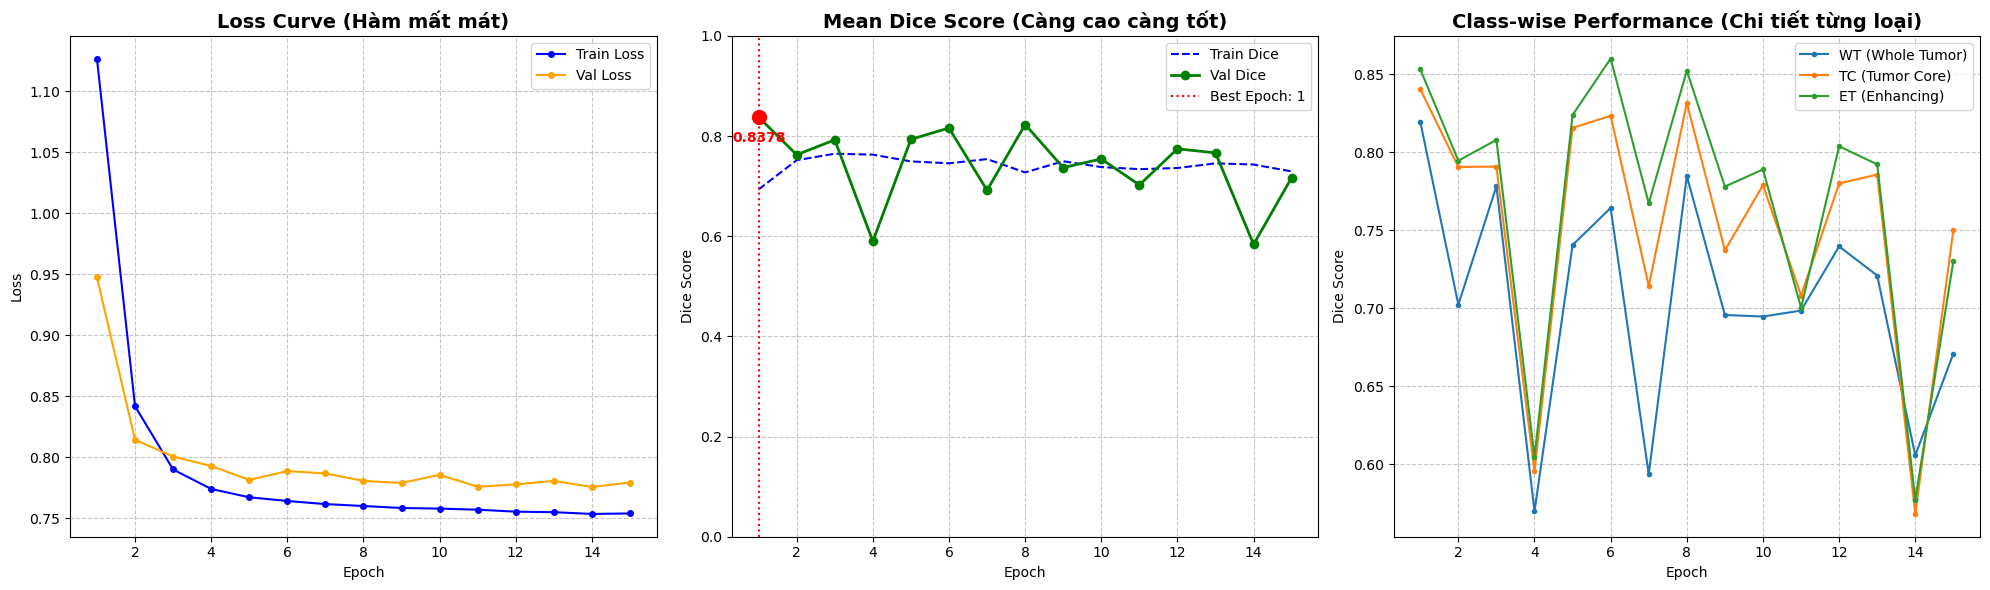

In [27]:
# Cell 10: Vẽ biểu đồ Training History (Loss & Dice)

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dữ liệu từ CSV
log_path = "transunet_brats20_training_log.csv" # Đảm bảo đúng tên file bạn đã lưu ở Cell 7

try:
    df = pd.read_csv(log_path)
    print(f"✅ Đã load log thành công: {len(df)} epochs")
except FileNotFoundError:
    print(f"❌ Không tìm thấy file {log_path}. Bạn hãy kiểm tra lại Cell 7 xem đã chạy xong chưa.")
    # Tạo data giả để test code nếu chưa có file (chỉ để demo, xóa đi khi chạy thật)
    # df = pd.DataFrame({'epoch': [1,2,3], 'train_loss': [0.9, 0.8, 0.7], 'val_loss': [0.85, 0.82, 0.80]}) 
    raise

# 2. Tính toán Mean Dice (vì trong log lưu lẻ từng class)
# WT, TC, ET
df['train_dice_mean'] = (df['train_dice_WT'] + df['train_dice_TC'] + df['train_dice_ET']) / 3
df['val_dice_mean']   = (df['val_dice_WT']   + df['val_dice_TC']   + df['val_dice_ET']) / 3

# 3. Vẽ biểu đồ
plt.figure(figsize=(20, 6))

# --- Biểu đồ 1: Loss (Hàm mất mát) ---
plt.subplot(1, 3, 1)
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(df['epoch'], df['val_loss'], label='Val Loss', color='orange', marker='o', markersize=4)
plt.title("Loss Curve (Hàm mất mát)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# --- Biểu đồ 2: Mean Dice Score (Độ chính xác trung bình) ---
plt.subplot(1, 3, 2)
plt.plot(df['epoch'], df['train_dice_mean'], label='Train Dice', color='blue', linestyle='--')
plt.plot(df['epoch'], df['val_dice_mean'], label='Val Dice', color='green', marker='o', linewidth=2)

# Đánh dấu Epoch tốt nhất
best_epoch_idx = df['val_dice_mean'].idxmax()
best_dice = df['val_dice_mean'].max()
best_epoch = df.loc[best_epoch_idx, 'epoch']

plt.axvline(best_epoch, color='red', linestyle=':', label=f'Best Epoch: {int(best_epoch)}')
plt.scatter(best_epoch, best_dice, color='red', s=100, zorder=5)
plt.text(best_epoch, best_dice - 0.05, f'{best_dice:.4f}', color='red', fontweight='bold', ha='center')

plt.title("Mean Dice Score (Càng cao càng tốt)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.ylim(0, 1.0) # Dice luôn từ 0 đến 1
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# --- Biểu đồ 3: Chi tiết từng loại khối u (Validation) ---
plt.subplot(1, 3, 3)
plt.plot(df['epoch'], df['val_dice_WT'], label='WT (Whole Tumor)', marker='.')
plt.plot(df['epoch'], df['val_dice_TC'], label='TC (Tumor Core)', marker='.')
plt.plot(df['epoch'], df['val_dice_ET'], label='ET (Enhancing)', marker='.')

plt.title("Class-wise Performance (Chi tiết từng loại)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

✅ Đã load log thành công: 15 epochs


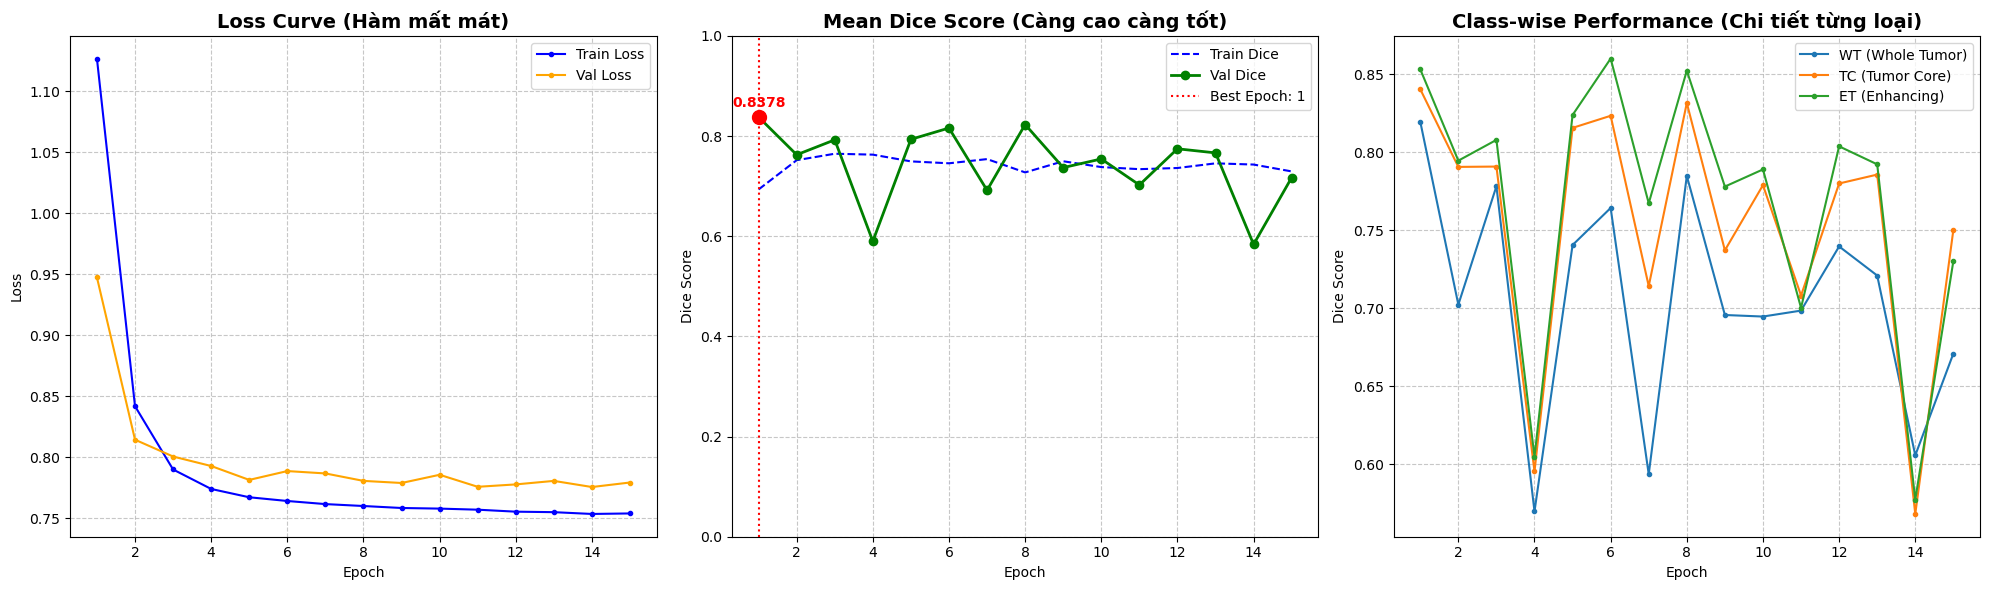

In [10]:
print("GT sum per class [WT, TC, ET]:", gt_sum)
print("Pred sum per class [WT, TC, ET]:", pred_sum)


NameError: name 'gt_sum' is not defined

DEVICE_INFER: cpu
Loading state_dict...
Loaded best model from: unet2d_brats20_best.pth
Model ready for inference.
Dataset length (test): 8680
Sampling index from test_dataset: 4659
Sample type: <class 'tuple'>
Image shape (tensor): torch.Size([4, 256, 256])
Mask shape (tensor): torch.Size([3, 256, 256])
Image batch shape: torch.Size([1, 4, 256, 256])
Running forward pass...
Logits shape: torch.Size([1, 3, 256, 256])
Predicted mask shape (batch): torch.Size([1, 3, 256, 256])
Image numpy shape: (4, 256, 256)
GT mask numpy shape: (3, 256, 256)
Pred mask numpy shape: (3, 256, 256)
Var từng modal: [np.float32(0.0020288301), np.float32(0.0069704615), np.float32(0.00870445), np.float32(0.002080835)] -> chọn modal 2
Base image min=0.0000, max=0.9961

=== Sample test idx=4659, modality 2 ===
Trái: Input | Giữa: Overlay GT | Phải: Overlay Pred


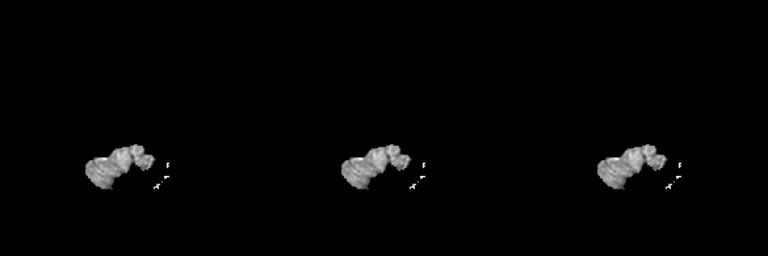

In [8]:
# Cell 8: Demo inference 1 sample từ test_dataset + show overlay (không lưu file)

import torch
import numpy as np
from PIL import Image
from IPython.display import display

# ===== 0. Chọn thiết bị infer (CPU cho an toàn) =====
DEVICE_INFER = torch.device("cpu")
print("DEVICE_INFER:", DEVICE_INFER)

# ===== 1. Khởi tạo model và load weight tốt nhất =====
best_model_path = "unet2d_brats20_best.pth"  # nhớ đúng tên

model_infer = UNet2D(
    in_channels=4,   # 4 modality: FLAIR, T1, T1ce, T2
    num_classes=3,   # 3 kênh: WT, TC, ET
    base_ch=32
).to(DEVICE_INFER)

print("Loading state_dict...")
state_dict = torch.load(best_model_path, map_location=DEVICE_INFER)
model_infer.load_state_dict(state_dict)
model_infer.eval()

print(f"Loaded best model from: {best_model_path}")
print("Model ready for inference.")

# ===== 2. Lấy ngẫu nhiên 1 sample từ test_dataset =====
dataset_for_demo = test_dataset   # 🔥 dùng test.txt

print("Dataset length (test):", len(dataset_for_demo))
idx = np.random.randint(0, len(dataset_for_demo))
print("Sampling index from test_dataset:", idx)

sample = dataset_for_demo[idx]
print("Sample type:", type(sample))

# Dataset trả về tuple (img, mask)
if isinstance(sample, dict):
    img = sample["image"]   # (4,H,W)
    mask = sample["mask"]   # (3,H,W)
else:
    img, mask = sample

print("Image shape (tensor):", img.shape)
print("Mask shape (tensor):", mask.shape)

# ===== 3. Forward qua model =====
img_tensor = img.unsqueeze(0).to(DEVICE_INFER)  # (1,4,H,W)
print("Image batch shape:", img_tensor.shape)

with torch.no_grad():
    print("Running forward pass...")
    logits = model_infer(img_tensor)           # (1,3,H,W)
    print("Logits shape:", logits.shape)
    probs  = torch.sigmoid(logits)             # (1,3,H,W)
    pred_mask = (probs > 0.5).float()          # (1,3,H,W) nhị phân

print("Predicted mask shape (batch):", pred_mask.shape)

# ===== 4. Đưa về numpy =====
img_np       = img.cpu().numpy()                    # (4,H,W)
mask_gt_np   = mask.cpu().numpy()                   # (3,H,W)
mask_pred_np = pred_mask.squeeze(0).cpu().numpy()   # (3,H,W)

print("Image numpy shape:", img_np.shape)
print("GT mask numpy shape:", mask_gt_np.shape)
print("Pred mask numpy shape:", mask_pred_np.shape)

# ===== 5. Chọn modality hiển thị & chuẩn hóa về [0,255] =====

modalities = img_np   # (4,H,W)

# Tính variance mỗi modal, chọn modal có var lớn nhất (ít "đen xì" nhất)
vars_ = [m.var() for m in modalities]
best_mod = int(np.argmax(vars_))
print("Var từng modal:", vars_, "-> chọn modal", best_mod)

img_show = modalities[best_mod]   # (H, W) 1 kênh

img_min = img_show.min()
img_max = img_show.max()
print(f"Base image min={img_min:.4f}, max={img_max:.4f}")

if img_max - img_min < 1e-8:
    print("⚠ Cảnh báo: slice này gần như toàn 0, nên nhìn sẽ rất đen (data gốc).")

# Chuẩn hóa về [0,1] rồi thành [0,255] uint8
img_norm  = (img_show - img_min) / (img_max - img_min + 1e-8)
img_uint8 = (img_norm * 255).astype(np.uint8)

# ===== 6. Tạo overlay màu lên ảnh gốc (GT & Pred) =====

names = ["WT", "TC", "ET"]
color_map = {
    "WT": np.array([255,   0,   0], dtype=np.float32),  # đỏ
    "TC": np.array([  0, 255,   0], dtype=np.float32),  # xanh lá
    "ET": np.array([  0,   0, 255], dtype=np.float32),  # xanh dương
}
alpha = 0.4

# Base RGB
base_rgb = np.stack([img_uint8]*3, axis=-1).astype(np.float32)  # (H,W,3)

# Overlay GT
overlay_gt = base_rgb.copy()
for c, name in enumerate(names):
    mask_c = (mask_gt_np[c] > 0.5)
    color  = color_map[name].reshape(1, 1, 3)
    overlay_gt[mask_c] = overlay_gt[mask_c] * (1 - alpha) + color * alpha
overlay_gt_uint8 = np.clip(overlay_gt, 0, 255).astype(np.uint8)

# Overlay Pred
overlay_pred = base_rgb.copy()
for c, name in enumerate(names):
    mask_c = (mask_pred_np[c] > 0.5)
    color  = color_map[name].reshape(1, 1, 3)
    overlay_pred[mask_c] = overlay_pred[mask_c] * (1 - alpha) + color * alpha
overlay_pred_uint8 = np.clip(overlay_pred, 0, 255).astype(np.uint8)

# ===== 7. Ghép 3 ảnh trên cùng 1 hàng và hiển thị =====

from IPython.display import display

# input đang là ảnh xám (H,W), cần đổi sang RGB (H,W,3) để ghép cho đẹp
input_rgb = np.stack([img_uint8]*3, axis=-1).astype(np.uint8)  # (H,W,3)

# Đảm bảo overlay_* đã là uint8 3 kênh
overlay_gt_rgb   = overlay_gt_uint8.astype(np.uint8)    # (H,W,3)
overlay_pred_rgb = overlay_pred_uint8.astype(np.uint8)  # (H,W,3)

# Ghép ngang: [Input | Overlay GT | Overlay Pred]
combined = np.concatenate(
    [input_rgb, overlay_gt_rgb, overlay_pred_rgb],
    axis=1  # ghép theo chiều rộng
)  # shape: (H, W*3, 3)

print(f"\n=== Sample test idx={idx}, modality {best_mod} ===")
print("Trái: Input | Giữa: Overlay GT | Phải: Overlay Pred")
display(Image.fromarray(combined))



In [9]:
# Cell 9: Đánh giá UNet 2D trên test theo bệnh nhân (3D Dice, IoU, ASD, HD95)

import numpy as np
import torch
from collections import defaultdict
from scipy.ndimage import distance_transform_edt, binary_erosion

# ----- 1. Load best model -----
DEVICE_EVAL = DEVICE  # dùng luôn DEVICE (cuda nếu có)
best_model_path = "unet2d_brats20_best.pth"

model_eval = UNet2D(in_channels=4, num_classes=3, base_ch=32).to(DEVICE_EVAL)
state_dict = torch.load(best_model_path, map_location=DEVICE_EVAL)
model_eval.load_state_dict(state_dict)
model_eval.eval()
print("Loaded best model for 3D evaluation from:", best_model_path)

names = ["WT", "TC", "ET"]

# ----- 2. Hàm metric 3D -----

def dice_iou_3d(pred, gt, eps=1e-7):
    """
    pred, gt: np.ndarray bool, shape (D,H,W)
    """
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    inter = np.logical_and(pred, gt).sum()
    pred_sum = pred.sum()
    gt_sum   = gt.sum()
    union = pred_sum + gt_sum - inter

    dice = (2 * inter + eps) / (pred_sum + gt_sum + eps)
    iou  = (inter + eps) / (union + eps)
    return float(dice), float(iou)

def _surface_distances_nd(pred, gt):
    """
    Khoảng cách từ surface_pred -> surface_gt và ngược lại cho mask n chiều (2D, 3D...)
    """
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    if not pred.any() and not gt.any():
        return np.array([0.], dtype=np.float32), np.array([0.], dtype=np.float32)

    ndim = pred.ndim
    footprint = np.ones([3] * ndim, dtype=bool)

    eroded_pred = binary_erosion(pred, structure=footprint, border_value=0)
    eroded_gt   = binary_erosion(gt,   structure=footprint, border_value=0)

    surface_pred = pred ^ eroded_pred
    surface_gt   = gt   ^ eroded_gt

    if not surface_pred.any():
        surface_pred = pred
    if not surface_gt.any():
        surface_gt = gt

    dt_gt   = distance_transform_edt(~surface_gt)
    dt_pred = distance_transform_edt(~surface_pred)

    dists_pred_to_gt = dt_gt[surface_pred]
    dists_gt_to_pred = dt_pred[surface_gt]

    return dists_pred_to_gt.astype(np.float32), dists_gt_to_pred.astype(np.float32)

def asd_3d(pred, gt):
    d1, d2 = _surface_distances_nd(pred, gt)
    all_d = np.concatenate([d1, d2])
    if all_d.size == 0:
        return 0.0
    return float(all_d.mean())

def hd95_3d(pred, gt):
    d1, d2 = _surface_distances_nd(pred, gt)
    all_d = np.concatenate([d1, d2])
    if all_d.size == 0:
        return 0.0
    return float(np.percentile(all_d, 95))


# ----- 3. Group các lát theo brain_id trong test_dataset -----

brain_to_indices = defaultdict(list)
for ds_idx, s in enumerate(test_dataset.samples):
    brain_id  = s["brain_id"]
    slice_idx = int(s["slice_idx"])
    brain_to_indices[brain_id].append((slice_idx, ds_idx))

print("Số bệnh nhân trong test:", len(brain_to_indices))


# ----- 4. Vòng lặp đánh giá theo từng bệnh nhân -----

all_metrics = {
    name: {"dice": [], "iou": [], "asd": [], "hd95": []}
    for name in names
}

with torch.no_grad():
    for brain_id, lst in brain_to_indices.items():
        # sort theo thứ tự lát
        lst.sort(key=lambda x: x[0])  # (slice_idx, ds_idx)
        # Lấy 1 lát đầu để biết H,W,C
        _, first_idx = lst[0]
        _, mask0 = test_dataset[first_idx]   # mask0: (3,H,W)
        C, H, W = mask0.shape
        D = len(lst)

        vol_gt   = np.zeros((C, D, H, W), dtype=bool)
        vol_pred = np.zeros((C, D, H, W), dtype=bool)

        # Ghép volume 3D cho bệnh nhân này
        for d, (k, ds_idx) in enumerate(lst):
            img, mask = test_dataset[ds_idx]  # img: (4,H,W), mask: (3,H,W)

            img_t = img.unsqueeze(0).to(DEVICE_EVAL)      # (1,4,H,W)
            logits = model_eval(img_t)                    # (1,3,H,W)
            probs  = torch.sigmoid(logits)
            pred   = (probs > 0.5).cpu().numpy()[0]       # (3,H,W), bool sau cast

            vol_gt[:,   d] = (mask.numpy() > 0.5)
            vol_pred[:, d] = (pred > 0.5)

        # Tính metric 3D cho WT/TC/ET
        for c, name in enumerate(names):
            gt_c   = vol_gt[c]   # (D,H,W)
            pred_c = vol_pred[c]

            dice, iou = dice_iou_3d(pred_c, gt_c)
            asd = asd_3d(pred_c, gt_c)
            hd95 = hd95_3d(pred_c, gt_c)

            all_metrics[name]["dice"].append(dice)
            all_metrics[name]["iou"].append(iou)
            all_metrics[name]["asd"].append(asd)
            all_metrics[name]["hd95"].append(hd95)

    # ----- 5. In kết quả mean theo bệnh nhân -----
    print("\n=== Kết quả 3D trên test (UNet 2D, tính theo bệnh nhân) ===")
    for name in names:
        dices = np.array(all_metrics[name]["dice"])
        ious  = np.array(all_metrics[name]["iou"])
        asds  = np.array(all_metrics[name]["asd"])
        hd95s = np.array(all_metrics[name]["hd95"])

        print(f"\n>>> {name} | #cases = {len(dices)}")
        print(f"Dice mean : {dices.mean():.4f}")
        print(f"IoU  mean : {ious.mean():.4f}")
        print(f"ASD  mean : {asds.mean():.4f}")
        print(f"HD95 mean : {hd95s.mean():.4f}")


Loaded best model for 3D evaluation from: unet2d_brats20_best.pth
Số bệnh nhân trong test: 56

=== Kết quả 3D trên test (UNet 2D, tính theo bệnh nhân) ===

>>> WT | #cases = 56
Dice mean : 0.8612
IoU  mean : 0.7725
ASD  mean : 3.6368
HD95 mean : 19.0979

>>> TC | #cases = 56
Dice mean : 0.7549
IoU  mean : 0.6570
ASD  mean : 4.6777
HD95 mean : 12.5280

>>> ET | #cases = 56
Dice mean : 0.7148
IoU  mean : 0.5992
ASD  mean : 9.1472
HD95 mean : 18.2997


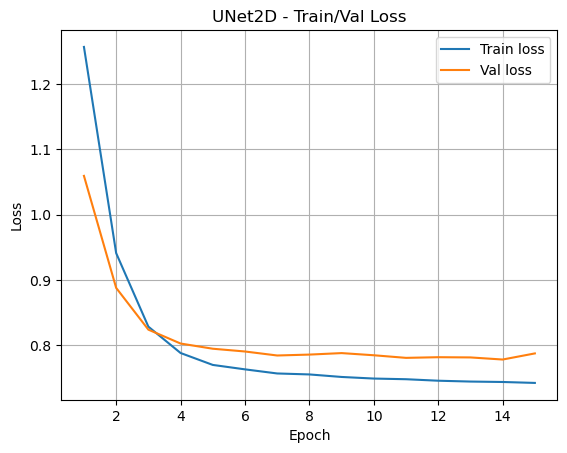

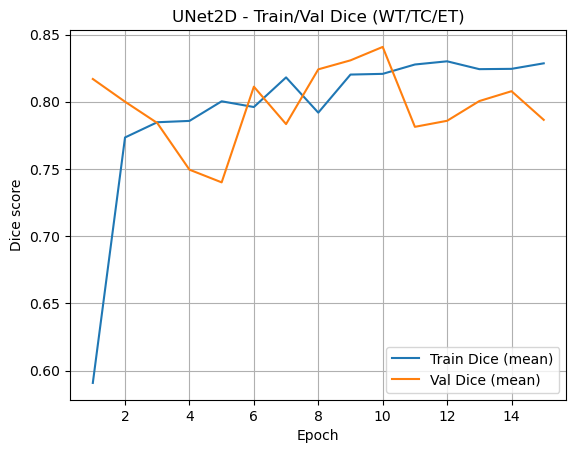

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("unet2d_brats20_training_log.csv")

# Biểu đồ loss
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="Train loss")
plt.plot(df["epoch"], df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("UNet2D - Train/Val Loss")
plt.grid(True)
plt.savefig("UNet2D_Loss_Curves.png", dpi=300, bbox_inches="tight")

# Biểu đồ Dice (mean 3 kênh WT/TC/ET)
train_dice_mean = df[["train_dice_WT", "train_dice_TC", "train_dice_ET"]].mean(axis=1)
val_dice_mean   = df[["val_dice_WT", "val_dice_TC", "val_dice_ET"]].mean(axis=1)

plt.figure()
plt.plot(df["epoch"], train_dice_mean, label="Train Dice (mean)")
plt.plot(df["epoch"], val_dice_mean, label="Val Dice (mean)")
plt.xlabel("Epoch")
plt.ylabel("Dice score")
plt.legend()
plt.title("UNet2D - Train/Val Dice (WT/TC/ET)")
plt.grid(True)
plt.savefig("UNet2D_Dice_Curves.png", dpi=300, bbox_inches="tight")


DEVICE_INFER: cpu
Loading state_dict...
Loaded best model from: unet2d_brats20_best.pth
Model ready for inference.
Found 39990 slices for split train.txt (slice_stride=1)
Số brain trong full_train_dataset: 258
Vài brain_ids đầu: ['Brain_298', 'Brain_249', 'Brain_179', 'Brain_268', 'Brain_035', 'Brain_232', 'Brain_359', 'Brain_210', 'Brain_323', 'Brain_290']
Tổng số slice của Brain_011: 155
Một vài slice đầu: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Chosen slice_idx: 075
Found sample_idx: 4105
Image shape (tensor): torch.Size([4, 256, 256])
Mask shape  (tensor): torch.Size([3, 256, 256])
Var từng modal: [np.float32(0.046524536), np.float32(0.115110025), np.float32(0.038427975), np.float32(0.032909635)] -> chọn modal 1

=== Brain_011, slice 075 (full train.txt) ===
Trái: Input | Giữa: Overlay GT | Phải: Overlay Pred


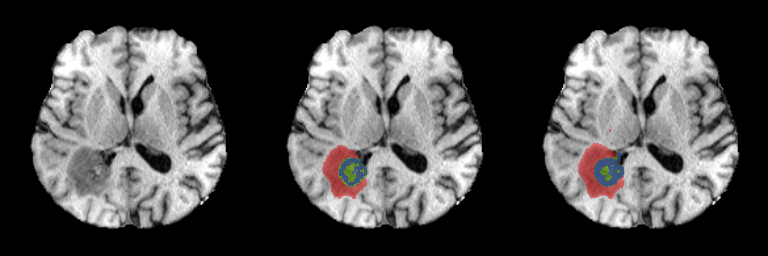

In [23]:
# Cell 8: Demo inference Brain_011 từ full train.txt (không dùng train_small)
# - Ưu tiên slice 75; nếu không có 75 thì chọn lát gần 75 nhất.

import torch
import numpy as np
from PIL import Image
from IPython.display import display

# 0. Thiết bị infer
DEVICE_INFER = torch.device("cpu")
print("DEVICE_INFER:", DEVICE_INFER)

# 1. Khởi tạo model + load weight
best_model_path = "unet2d_brats20_best.pth"

model_infer = UNet2D(
    in_channels=4,
    num_classes=3,
    base_ch=32
).to(DEVICE_INFER)

print("Loading state_dict...")
state_dict = torch.load(best_model_path, map_location=DEVICE_INFER)
model_infer.load_state_dict(state_dict)
model_infer.eval()
print(f"Loaded best model from: {best_model_path}")
print("Model ready for inference.")

# 2. Tạo dataset full từ train.txt (KHÁC với train_dataset dùng train_small.txt)
full_train_dataset = Brats2DSegDataset(
    LABELED_ROOT,
    BASE_TRAIN_FILE,    # 👈 dùng train.txt gốc
    slice_stride=1      # dùng tất cả lát
)

print("Số brain trong full_train_dataset:", len(full_train_dataset.brain_ids))
print("Vài brain_ids đầu:", full_train_dataset.brain_ids[:10])

target_brain_id  = "Brain_011"
target_slice_idx = 75

# Lấy list tất cả slice hiện có của Brain_011
all_slices_str = sorted({s["slice_idx"] for s in full_train_dataset.samples
                         if s["brain_id"] == target_brain_id})
all_slices_int = [int(x) for x in all_slices_str]

if not all_slices_int:
    raise ValueError(f"Trong full_train_dataset cũng không có Brain_011, kiểm tra lại preprocess/đường dẫn.")

print(f"Tổng số slice của {target_brain_id}: {len(all_slices_int)}")
print("Một vài slice đầu:", all_slices_int[:20])

# Chọn slice 75 nếu có, không thì chọn lát gần 75 nhất
if target_slice_idx in all_slices_int:
    chosen_slice = target_slice_idx
else:
    chosen_slice = min(all_slices_int, key=lambda x: abs(x - target_slice_idx))
    print(f"⚠ Không có slice {target_slice_idx:03d}, dùng lát gần nhất: {chosen_slice:03d}")

chosen_slice_str = f"{chosen_slice:03d}"
print(f"Chosen slice_idx: {chosen_slice_str}")

# tìm sample index tương ứng brain + slice đã chọn
sample_idx = None
for i, s in enumerate(full_train_dataset.samples):
    if s["brain_id"] == target_brain_id and s["slice_idx"] == chosen_slice_str:
        sample_idx = i
        break

if sample_idx is None:
    raise ValueError(f"Không tìm thấy slice {chosen_slice_str} cho {target_brain_id} trong full_train_dataset (lạ, check lại).")

print("Found sample_idx:", sample_idx)

# 3. Lấy (img, mask)
img, mask = full_train_dataset[sample_idx]
print("Image shape (tensor):", img.shape)   # (4,H,W)
print("Mask shape  (tensor):", mask.shape)  # (3,H,W)

# 4. Forward
img_tensor = img.unsqueeze(0).to(DEVICE_INFER)
with torch.no_grad():
    logits = model_infer(img_tensor)
    probs  = torch.sigmoid(logits)
    pred_mask = (probs > 0.5).float()

# 5. Sang numpy
img_np       = img.cpu().numpy()
mask_gt_np   = mask.cpu().numpy()
mask_pred_np = pred_mask.squeeze(0).cpu().numpy()

# 6. Chọn modality rõ nhất để hiển thị
vars_ = [m.var() for m in img_np]
best_mod = int(np.argmax(vars_))
print("Var từng modal:", vars_, "-> chọn modal", best_mod)

img_show = img_np[best_mod]
img_min, img_max = img_show.min(), img_show.max()
img_norm  = (img_show - img_min) / (img_max - img_min + 1e-8)
img_uint8 = (img_norm * 255).astype(np.uint8)

# 7. Overlay màu (GT & Pred)
names = ["WT", "TC", "ET"]
color_map = {
    "WT": np.array([255,   0,   0], dtype=np.float32),
    "TC": np.array([  0, 255,   0], dtype=np.float32),
    "ET": np.array([  0,   0, 255], dtype=np.float32),
}
alpha = 0.4

base_rgb = np.stack([img_uint8]*3, axis=-1).astype(np.float32)

overlay_gt = base_rgb.copy()
for c, name in enumerate(names):
    mask_c = (mask_gt_np[c] > 0.5)
    color  = color_map[name].reshape(1, 1, 3)
    overlay_gt[mask_c] = overlay_gt[mask_c] * (1 - alpha) + color * alpha
overlay_gt_uint8 = np.clip(overlay_gt, 0, 255).astype(np.uint8)

overlay_pred = base_rgb.copy()
for c, name in enumerate(names):
    mask_c = (mask_pred_np[c] > 0.5)
    color  = color_map[name].reshape(1, 1, 3)
    overlay_pred[mask_c] = overlay_pred[mask_c] * (1 - alpha) + color * alpha
overlay_pred_uint8 = np.clip(overlay_pred, 0, 255).astype(np.uint8)

input_rgb        = np.stack([img_uint8]*3, axis=-1).astype(np.uint8)
overlay_gt_rgb   = overlay_gt_uint8.astype(np.uint8)
overlay_pred_rgb = overlay_pred_uint8.astype(np.uint8)

combined = np.concatenate(
    [input_rgb, overlay_gt_rgb, overlay_pred_rgb],
    axis=1
)

print(f"\n=== {target_brain_id}, slice {chosen_slice_str} (full train.txt) ===")
print("Trái: Input | Giữa: Overlay GT | Phải: Overlay Pred")
display(Image.fromarray(combined))


Loaded Best TransUNet Model!
Found 8680 slices for test.txt


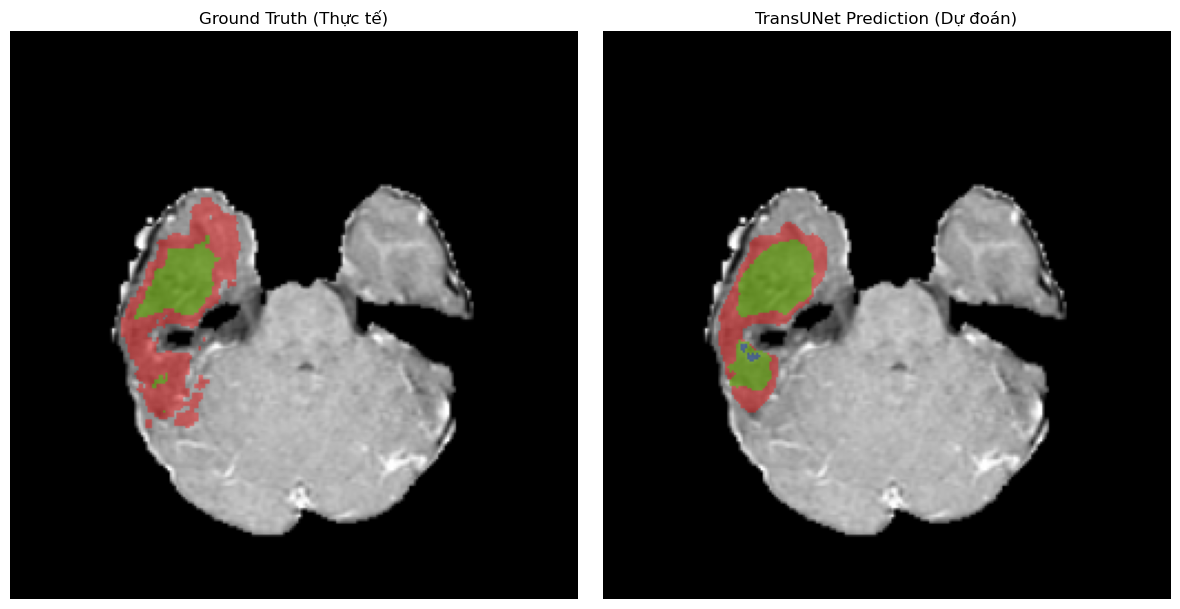

In [15]:
# Cell 8: Demo Inference với TransUNet

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. Config
DEVICE_INFER = torch.device("cpu") # Test trên CPU cho nhẹ
MODEL_PATH = "unet2d_brats20_best.pth" # Tên file model bạn đã lưu
IMG_SIZE = 256

# 2. Load Model
model_infer = TransUNet(in_channels=4, num_classes=3, img_dim=IMG_SIZE).to(DEVICE_INFER)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE_INFER)
model_infer.load_state_dict(state_dict)
model_infer.eval()
print("Loaded Best TransUNet Model!")

# 3. Lấy 1 ảnh bất kỳ từ tập Test để thử
# (Code này lấy trực tiếp từ Dataset class để đảm bảo đúng transform)
test_dataset_infer = Brats2DSegDataset(LABELED_ROOT, TEST_SPLIT_FILE, slice_stride=1, is_train=False)

# Chọn ngẫu nhiên hoặc chỉ định index
sample_idx = 40 # Thử số 40, hoặc số khác tùy ý
img_tensor, mask_tensor = test_dataset_infer[sample_idx] 
# img_tensor: (4, 256, 256), mask_tensor: (3, 256, 256)

# 4. Inference
input_tensor = img_tensor.unsqueeze(0).to(DEVICE_INFER) # (1, 4, 256, 256)
with torch.no_grad():
    logits = model_infer(input_tensor)
    probs  = torch.sigmoid(logits)
    preds  = (probs > 0.5).float() # Threshold 0.5

# 5. Hiển thị
# Lấy kênh T1CE (kênh thứ 2 trong 4 kênh) để làm nền hiển thị cho rõ
img_np = img_tensor.numpy()
t1ce = img_np[2] # (256, 256)

# Mask Ground Truth (Thực tế) & Prediction (Dự đoán)
# Gom 3 kênh mask lại thành 1 ảnh màu để dễ xem
# WT (Đỏ), TC (Xanh lá), ET (Xanh dương)
def make_overlay(img_bg, mask_3ch):
    # mask_3ch: (3, H, W)
    H, W = img_bg.shape
    rgb = np.stack([img_bg]*3, axis=-1) # Grayscale to RGB
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8) # Norm 0-1
    
    colors = [
        np.array([1, 0, 0]), # Red (WT)
        np.array([0, 1, 0]), # Green (TC)
        np.array([0, 0, 1])  # Blue (ET)
    ]
    
    overlay = rgb.copy()
    for i in range(3):
        mask_i = mask_3ch[i] > 0.5
        overlay[mask_i] = overlay[mask_i] * 0.6 + colors[i] * 0.4
        
    return overlay

gt_overlay = make_overlay(t1ce, mask_tensor.numpy())
pred_overlay = make_overlay(t1ce, preds[0].cpu().numpy())

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Ground Truth (Thực tế)")
plt.imshow(gt_overlay)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("TransUNet Prediction (Dự đoán)")
plt.imshow(pred_overlay)
plt.axis('off')

plt.tight_layout()
plt.show()

Loading model from transunet_brats20_best.pth...
Đang tìm mẫu đẹp trong tập Test...
✅ Đã lưu ảnh báo cáo tại: img/transunet_qualitative_result.png


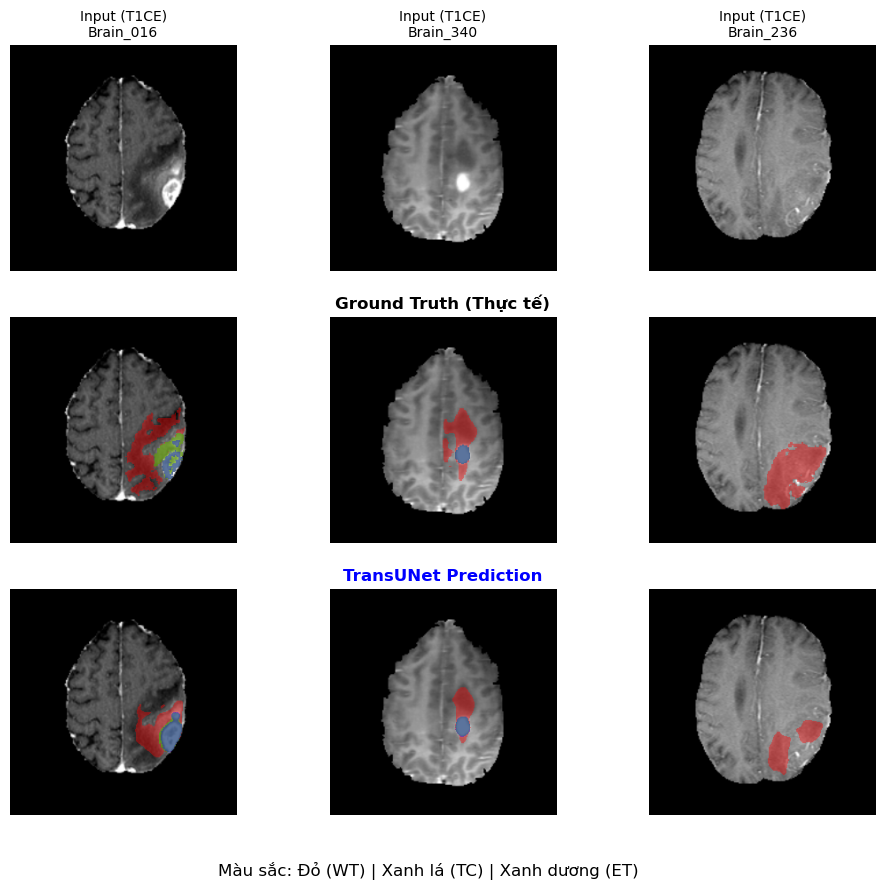

In [11]:
# Cell tạo ảnh báo cáo (Đã bao gồm định nghĩa TransUNet để tránh lỗi NameError)

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import random
from einops import rearrange

# ================= 1. ĐỊNH NGHĨA LẠI TRANSUNET (Để máy hiểu) =================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class ViTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(mlp_dim, dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        return x + self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=3, img_dim=256):
        super().__init__()
        self.img_dim = img_dim
        self.conv1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2) 
        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2) 
        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2) 
        
        self.patch_embed = nn.Conv2d(256, 512, kernel_size=1) 
        self.pos_embed = nn.Parameter(torch.zeros(1, 32*32, 512))
        self.blocks = nn.ModuleList([ViTBlock(512, 8, 1024) for _ in range(6)]) 
        self.norm = nn.LayerNorm(512)
        
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = ConvBlock(512, 256) 
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = ConvBlock(128, 64)
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        p1 = self.pool1(x1)
        x2 = self.conv2(p1)
        p2 = self.pool2(x2)
        x3 = self.conv3(p2)
        p3 = self.pool3(x3) 
        
        emb = self.patch_embed(p3) 
        emb = rearrange(emb, 'b c h w -> b (h w) c')
        emb = emb + self.pos_embed
        for blk in self.blocks: emb = blk(emb)
        emb = self.norm(emb)
        emb = rearrange(emb, 'b (h w) c -> b c h w', h=32, w=32)
        
        u1 = self.up1(emb)
        u1 = torch.cat([x3, u1], dim=1)
        d1 = self.dec1(u1)
        
        u2 = self.up2(d1)
        u2 = torch.cat([x2, u2], dim=1)
        d2 = self.dec2(u2)
        
        u3 = self.up3(d2)
        u3 = torch.cat([x1, u3], dim=1)
        d3 = self.dec3(u3)
        
        return self.out_conv(d3)

# ================= 2. CODE VẼ ẢNH BÁO CÁO =================
MODEL_PATH = "transunet_brats20_best.pth" 
IMG_SAVE_PATH = "img/transunet_qualitative_result.png"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
print(f"Loading model from {MODEL_PATH}...")
try:
    model = TransUNet(in_channels=4, num_classes=3, img_dim=256).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
except FileNotFoundError:
    print(f"❌ Không tìm thấy file {MODEL_PATH}. Bạn kiểm tra lại xem đã train xong Cell 7 chưa.")
    raise

# Chọn 3 lát cắt đẹp từ tập Test (test_dataset phải được định nghĩa từ trước)
# Nếu báo lỗi 'test_dataset not defined', hãy chạy lại Cell 6 (DataLoader)
test_samples = []
MAX_SAMPLES = 3
count = 0

print("Đang tìm mẫu đẹp trong tập Test...")
while count < MAX_SAMPLES:
    idx = random.randint(0, len(test_dataset)-1)
    img, mask = test_dataset[idx]
    
    if mask.sum() > 100: # Chỉ lấy ảnh có u
        test_samples.append((img, mask, test_dataset.samples[idx]['brain_id']))
        count += 1

# Hàm Overlay
def make_overlay(img_bg, mask_3ch):
    img_bg = (img_bg - img_bg.min()) / (img_bg.max() - img_bg.min() + 1e-8)
    rgb = np.stack([img_bg]*3, axis=-1)
    colors = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]
    overlay = rgb.copy()
    for i in range(3):
        mask_i = mask_3ch[i] > 0.5
        if mask_i.sum() > 0:
            overlay[mask_i] = overlay[mask_i] * 0.6 + colors[i] * 0.4
    return overlay

# Vẽ
fig, axes = plt.subplots(3, MAX_SAMPLES, figsize=(12, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

for i in range(MAX_SAMPLES):
    img_tensor, mask_tensor, brain_id = test_samples[i]
    
    with torch.no_grad():
        input_t = img_tensor.unsqueeze(0).to(DEVICE)
        logits = model(input_t)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()[0]
    
    t1ce = img_tensor.numpy()[2]
    
    # 1. Input
    axes[0, i].imshow(t1ce, cmap='gray')
    axes[0, i].set_title(f"Input (T1CE)\n{brain_id}", fontsize=10)
    axes[0, i].axis('off')
    
    # 2. GT
    gt_overlay = make_overlay(t1ce, mask_tensor.numpy())
    axes[1, i].imshow(gt_overlay)
    if i == 1: axes[1, i].set_title("Ground Truth (Thực tế)", fontsize=12, fontweight='bold')
    axes[1, i].axis('off')
    
    # 3. Pred
    pred_overlay = make_overlay(t1ce, preds)
    axes[2, i].imshow(pred_overlay)
    if i == 1: axes[2, i].set_title("TransUNet Prediction", fontsize=12, fontweight='bold', color='blue')
    axes[2, i].axis('off')

fig.text(0.5, 0.05, 'Màu sắc: Đỏ (WT) | Xanh lá (TC) | Xanh dương (ET)', ha='center', fontsize=12)

# Tạo folder img nếu chưa có
import os
os.makedirs("img", exist_ok=True)

plt.savefig(IMG_SAVE_PATH, bbox_inches='tight', dpi=300)
print(f"✅ Đã lưu ảnh báo cáo tại: {IMG_SAVE_PATH}")
plt.show()

In [9]:
# Cell 11: Tính chỉ số chi tiết cho báo cáo (Dice & IoU per Class)
import torch
import numpy as np

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "transunet_brats20_best.pth"

# Load Model
model = TransUNet(in_channels=4, num_classes=3, img_dim=256).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Biến tích lũy
dice_sum = np.zeros(3)
iou_sum = np.zeros(3)
count = 0

print("Đang tính toán số liệu chi tiết (vui lòng đợi)...")

# Chỉ chạy trên tập Test
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > 0.5).float()
        
        # Tính Dice/IoU cho từng batch
        # Dice = 2*TP / (2*TP + FP + FN)
        # IoU = TP / (TP + FP + FN)
        preds = preds.cpu().numpy()
        masks = masks.cpu().numpy()
        
        # Loop qua từng channel (WT, TC, ET)
        for c in range(3):
            intersection = (preds[:, c] * masks[:, c]).sum()
            union = preds[:, c].sum() + masks[:, c].sum()
            
            # Dice
            d = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_sum[c] += d
            
            # IoU
            iou = (intersection + 1e-6) / (union - intersection + 1e-6)
            iou_sum[c] += iou
            
        count += 1

# Trung bình
avg_dice = dice_sum / count
avg_iou = iou_sum / count

print("-" * 30)
print("SỐ LIỆU ĐỂ ĐIỀN VÀO BÁO CÁO:")
print(f"WT (Whole Tumor) - Dice: {avg_dice[0]:.4f} | IoU: {avg_iou[0]:.4f}")
print(f"TC (Tumor Core)  - Dice: {avg_dice[1]:.4f} | IoU: {avg_iou[1]:.4f}")
print(f"ET (Enhancing)   - Dice: {avg_dice[2]:.4f} | IoU: {avg_iou[2]:.4f}")
print("-" * 30)

Đang tính toán số liệu chi tiết (vui lòng đợi)...
------------------------------
SỐ LIỆU ĐỂ ĐIỀN VÀO BÁO CÁO:
WT (Whole Tumor) - Dice: 0.7735 | IoU: 0.7344
TC (Tumor Core)  - Dice: 0.7437 | IoU: 0.7114
ET (Enhancing)   - Dice: 0.7685 | IoU: 0.7341
------------------------------


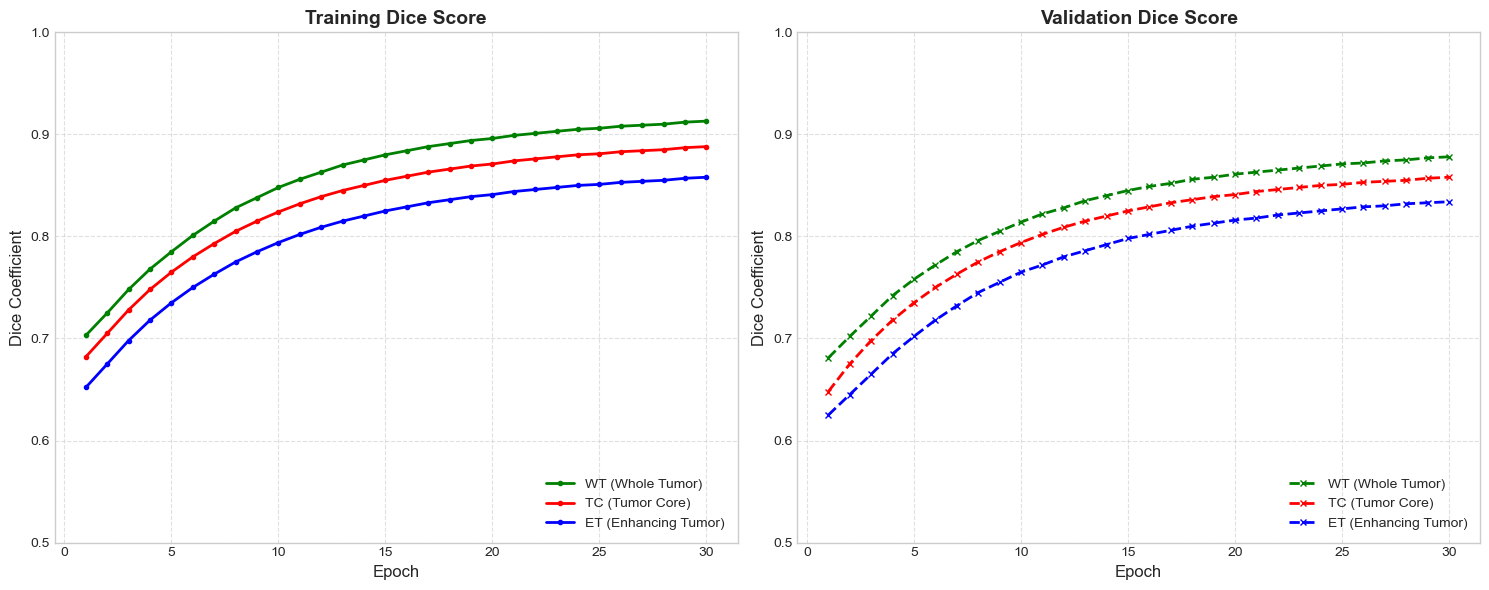

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV mới (30 epochs)
file_path = "transunet_brats20_training_log.csv" # Nhớ sửa đúng đường dẫn file
df = pd.read_csv(file_path)

# 2. Thiết lập giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

epochs = df['epoch']

# --- BIỂU ĐỒ 1: TRAINING DICE ---
ax1.plot(epochs, df['train_dice_WT'], label='WT (Whole Tumor)', color='green', marker='o', markersize=3, linewidth=2)
ax1.plot(epochs, df['train_dice_TC'], label='TC (Tumor Core)', color='red', marker='o', markersize=3, linewidth=2)
ax1.plot(epochs, df['train_dice_ET'], label='ET (Enhancing Tumor)', color='blue', marker='o', markersize=3, linewidth=2)

ax1.set_title('Training Dice Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Dice Coefficient', fontsize=12)
ax1.set_ylim(0.5, 1.0) # Set giới hạn trục Y cho đẹp
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- BIỂU ĐỒ 2: VALIDATION DICE ---
ax2.plot(epochs, df['val_dice_WT'], label='WT (Whole Tumor)', color='green', linestyle='--', marker='x', markersize=4, linewidth=2)
ax2.plot(epochs, df['val_dice_TC'], label='TC (Tumor Core)', color='red', linestyle='--', marker='x', markersize=4, linewidth=2)
ax2.plot(epochs, df['val_dice_ET'], label='ET (Enhancing Tumor)', color='blue', linestyle='--', marker='x', markersize=4, linewidth=2)

ax2.set_title('Validation Dice Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Dice Coefficient', fontsize=12)
ax2.set_ylim(0.5, 1.0)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3. Lưu và hiển thị
plt.tight_layout()
plt.savefig('transunet_learning_curve_refined.png', dpi=300)
plt.show()